In [ ]:
print("hello world")


hello world
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# העלמת אזהרות לא קריטיות כדי לשמור על מחברת נקייה
warnings.filterwarnings('ignore')

# עיצוב אחיד ויפה לגרפים
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
%matplotlib inline

# הגדרת נתיב הנתונים ביחס למיקום המחברת (יוצאים מ-notebooks ונכנסים ל-data)
DATA_DIR = Path("../data/processed_parquet")

print("הספריות נטענו והנתיב הוגדר בהצלחה!")

Matplotlib is building the font cache; this may take a moment.


הספריות נטענו והנתיב הוגדר בהצלחה!


In [5]:
import pandas as pd
from pathlib import Path

# הגדרת הנתיב לתיקיית הנתונים המעובדים שלנו
DATA_DIR = Path("../data/processed_parquet")
sema_path = DATA_DIR / "all_sema_emotions.parquet"

# טעינת הנתונים הגולמיים המקומיים
df_sema_local = pd.read_parquet(sema_path)

print("=== הנתונים הפסיכולוגיים המקומיים (VS Code) ===")
print(f"סה'כ שורות (תצפיות) בקובץ: {len(df_sema_local):,}")
print(f"סה'כ עמודות (משתנים): {len(df_sema_local.columns)}\n")

# בואי נבדוק כמה שורות מכילות חותמת זמן של סיום מענה (כמו המסנן שלך בקולאב)
valid_timestamps = df_sema_local['data.COMPLETED_TS'].notna().sum()
print(f"מתוך זה, כמות השורות עם חותמת זמן מדויקת (COMPLETED_TS): {valid_timestamps:,}")

print("\nהצצה לנתונים שלנו:")
display(df_sema_local.head())

=== הנתונים הפסיכולוגיים המקומיים (VS Code) ===
סה'כ שורות (תצפיות) בקובץ: 15,380
סה'כ עמודות (משתנים): 26

מתוך זה, כמות השורות עם חותמת זמן מדויקת (COMPLETED_TS): 6,959

הצצה לנתונים שלנו:


,_id,user_id,data.PARTICIPANT_ID,data.STUDY_ID,data.STUDY_NAME,data.STUDY_VERSION,data.SURVEY_ID,data.SURVEY_NAME,data.TRIGGER,data.START_END,...,data.TOTAL_RT,data.RAND_PROB,data.PLACE,data.PLACE_RT,data.OTHER,data.OTHER_RT,data.MOOD,data.MOOD_RT,data.STEPS,data.STEPS_RT
0,62cc7d568e3d174ffc0fbb47,621e2f1b67b776a240b3d87c,s523044002,uk96OixJ-,RAIS Consortium Experiment v2.0,5,BjTcu3Lg-,Context and Mood Survey,scheduled,1,...,10030,<no-response>,HOME,2440,<not-shown>,<not-shown>,TENSE/ANXIOUS,7590,<no-response>,<no-response>
1,62cc7d568e3d174ffc0fbb49,621e340467b776a2402d7982,s926411913,uk96OixJ-,RAIS Consortium Experiment v2.0,5,BjTcu3Lg-,Context and Mood Survey,scheduled,1,...,20029,<no-response>,WORK/SCHOOL,6428,<not-shown>,<not-shown>,TIRED,13601,<no-response>,<no-response>
2,62cc7d568e3d174ffc0fbb4a,621e346f67b776a24081744f,s567810400,uk96OixJ-,RAIS Consortium Experiment v2.0,5,BjTcu3Lg-,Context and Mood Survey,scheduled,1,...,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>
3,62cc7d568e3d174ffc0fbb4c,621e340467b776a2402d7982,s926411913,uk96OixJ-,RAIS Consortium Experiment v2.0,5,BjTcu3Lg-,Context and Mood Survey,scheduled,1,...,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>
4,62cc7d568e3d174ffc0fbb4e,621e333567b776a240a0c217,s837363231,uk96OixJ-,RAIS Consortium Experiment v2.0,5,BjTcu3Lg-,Context and Mood Survey,scheduled,1,...,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>


In [6]:
sema_path = DATA_DIR / "all_sema_emotions.parquet"

# טעינת הנתונים
df_sema = pd.read_parquet(sema_path)

print("=== פרופיל נתונים: דיווחי רגש (EMA) ===")
print(f"סך הכל שורות: {len(df_sema):,}")
print(f"סך הכל עמודות: {len(df_sema.columns)}")

# חישוב אחוז הערכים החסרים לכל עמודה
missing_pct = (df_sema.isnull().sum() / len(df_sema)) * 100
print("\nאחוז נתונים חסרים (Missing Values):")
print(missing_pct[missing_pct > 0].round(2).astype(str) + "%")

# הצגת 5 השורות הראשונות
display(df_sema.head())

=== פרופיל נתונים: דיווחי רגש (EMA) ===
סך הכל שורות: 15,380
סך הכל עמודות: 26

אחוז נתונים חסרים (Missing Values):
data.SURVEY_NAME      0.01%
data.STARTED_TS      54.34%
data.COMPLETED_TS    54.75%
data.EXPIRED_TS      45.66%
data.UPLOADED_TS     54.34%
data.PLACE            0.01%
data.MOOD             0.01%
data.STEPS            0.01%
dtype: str


,_id,user_id,data.PARTICIPANT_ID,data.STUDY_ID,data.STUDY_NAME,data.STUDY_VERSION,data.SURVEY_ID,data.SURVEY_NAME,data.TRIGGER,data.START_END,...,data.TOTAL_RT,data.RAND_PROB,data.PLACE,data.PLACE_RT,data.OTHER,data.OTHER_RT,data.MOOD,data.MOOD_RT,data.STEPS,data.STEPS_RT
0,62cc7d568e3d174ffc0fbb47,621e2f1b67b776a240b3d87c,s523044002,uk96OixJ-,RAIS Consortium Experiment v2.0,5,BjTcu3Lg-,Context and Mood Survey,scheduled,1,...,10030,<no-response>,HOME,2440,<not-shown>,<not-shown>,TENSE/ANXIOUS,7590,<no-response>,<no-response>
1,62cc7d568e3d174ffc0fbb49,621e340467b776a2402d7982,s926411913,uk96OixJ-,RAIS Consortium Experiment v2.0,5,BjTcu3Lg-,Context and Mood Survey,scheduled,1,...,20029,<no-response>,WORK/SCHOOL,6428,<not-shown>,<not-shown>,TIRED,13601,<no-response>,<no-response>
2,62cc7d568e3d174ffc0fbb4a,621e346f67b776a24081744f,s567810400,uk96OixJ-,RAIS Consortium Experiment v2.0,5,BjTcu3Lg-,Context and Mood Survey,scheduled,1,...,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>
3,62cc7d568e3d174ffc0fbb4c,621e340467b776a2402d7982,s926411913,uk96OixJ-,RAIS Consortium Experiment v2.0,5,BjTcu3Lg-,Context and Mood Survey,scheduled,1,...,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>
4,62cc7d568e3d174ffc0fbb4e,621e333567b776a240a0c217,s837363231,uk96OixJ-,RAIS Consortium Experiment v2.0,5,BjTcu3Lg-,Context and Mood Survey,scheduled,1,...,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>,<no-response>


## 1. סקירת מערך הנתונים הממוזג (רגש + פיזיולוגיה)
לאחר שהרצנו את סקריפט עיבוד הנתונים (`create_matches.py`), יצרנו טבלה הממזגת בין דיווחי הרגש של המשתמשים (SEMA) לבין נתוני הדופק שלהם מהשעון החכם. ההתאמה בוצעה כך שלכל דיווח רגשי הוצמד הדופק שנמדד בחצי השעה שקדמה לדיווח. 
בשלב זה נטען את הנתונים המעובדים ונבדוק את הנפח שלהם: כמה תצפיות הצלחנו להתאים, על כמה משתמשים מדובר, ומהו טווח הזמן של הנתונים כדי לוודא שיש לנו מספיק דאטה למחקר.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# עיצוב הגרפים
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
%matplotlib inline

# טעינת קובץ ההתאמות שיצרנו
DATA_DIR = Path("../data/processed_parquet")
matched_path = DATA_DIR / "matched_emotion_physio.parquet"
df_matched = pd.read_parquet(matched_path)

# --- מנגנון חכם למציאת עמודת המשתמש ---
possible_cols = ['user_id', 'id', 'participant_id', 'data.PARTICIPANT_ID', 'user_id_x', 'id_x']
user_col = None

for col in possible_cols:
    if col in df_matched.columns:
        user_col = col
        break

if user_col is None:
    print("שגיאה: לא הצלחתי למצוא את עמודת המשתמש! הנה רשימת העמודות שיש בקובץ:")
    print(df_matched.columns.tolist())
    raise ValueError("Missing User ID column")

print(f"הקוד משתמש בעמודה '{user_col}' לזיהוי הנבדקים.")
# ----------------------------------------

num_users = df_matched[user_col].nunique()
min_date = df_matched['timestamp'].min()
max_date = df_matched['timestamp'].max()

print("=== סיכום נתוני המחקר הממוזגים (רגש + דופק) ===")
print(f"סה'כ תצפיות (שורות) מותאמות: {len(df_matched):,}")
print(f"כמות משתמשים ייחודיים בקובץ: {num_users}")
print(f"טווח הזמן של הנתונים: מתאריך {min_date.strftime('%Y-%m-%d')} עד {max_date.strftime('%Y-%m-%d')}")

# הצצה לנתונים
display(df_matched.head())

הקוד משתמש בעמודה 'data.PARTICIPANT_ID' לזיהוי הנבדקים.
=== סיכום נתוני המחקר הממוזגים (רגש + דופק) ===
סה'כ תצפיות (שורות) מותאמות: 6,959
כמות משתמשים ייחודיים בקובץ: 64
טווח הזמן של הנתונים: מתאריך 2021-04-07 עד 2022-01-17


,_id,user_id_x,data.PARTICIPANT_ID,data.STUDY_ID,data.STUDY_NAME,data.STUDY_VERSION,data.SURVEY_ID,data.SURVEY_NAME,data.TRIGGER,data.START_END,...,data.MOOD,data.MOOD_RT,data.STEPS,data.STEPS_RT,timestamp,user_id_y,metric_type,value_numeric,value_text,confidence
0,62cc7d769bcd86f473dd983a,621e2e8e67b776a24055b564,s724143499,fS8DhqE6M,RAIS Consortium Experiment,24,kgTCueF5r,Context and Mood Survey,scheduled,1,...,HAPPY,5014,<no-response>,<no-response>,2021-05-25 10:17:00,621e2e8e67b776a24055b564,heart_rate,86.0,None,2.0
1,62cc7d769bcd86f473dd89bd,621e2e8e67b776a24055b564,s724143499,fS8DhqE6M,RAIS Consortium Experiment,25,RgoMOqKuT,Step Goal Survey,scheduled,1,...,<no-response>,<no-response>,14999,4410,2021-05-25 14:04:00,621e2e8e67b776a24055b564,heart_rate,79.0,None,1.0
2,62cc7d769bcd86f473dd98bc,621e2e8e67b776a24055b564,s724143499,fS8DhqE6M,RAIS Consortium Experiment,26,kgTCueF5r,Context and Mood Survey,scheduled,1,...,TIRED,7878,<no-response>,<no-response>,2021-05-25 18:35:00,621e2e8e67b776a24055b564,heart_rate,93.0,None,1.0
3,62cc7d769bcd86f473dd8aa3,621e2e8e67b776a24055b564,s724143499,fS8DhqE6M,RAIS Consortium Experiment,26,kgTCueF5r,Context and Mood Survey,scheduled,1,...,HAPPY,4120,<no-response>,<no-response>,2021-05-26 17:38:00,621e2e8e67b776a24055b564,heart_rate,91.0,None,1.0
4,62cc7d769bcd86f473dd860e,621e2e8e67b776a24055b564,s724143499,fS8DhqE6M,RAIS Consortium Experiment,26,kgTCueF5r,Context and Mood Survey,scheduled,1,...,HAPPY,1956,<no-response>,<no-response>,2021-05-27 11:51:00,621e2e8e67b776a24055b564,heart_rate,72.0,None,2.0


**מסקנות מהסקירה הראשונית:**
* **נפח נתונים:** יש לנו קרוב ל-7,000 תצפיות מותאמות שמגיעות מ-64 משתמשים שונים. זהו מדגם מצוין שבהחלט מספיק לאימון מודלים של למידת מכונה.
* **טווח זמנים:** הנתונים נאספו על פני כתשעה חודשים (אפריל 2021 עד ינואר 2022).
* **מבנה הנתונים:** גילינו שמדד הדופק נשמר בעמודה `value_numeric`, ושישנם דיווחים שבהם המשתמשים לא ענו על שאלת הרגש (הערך `<no-response>`), ולכן נצטרך לסנן אותם בניתוחים הבאים.

## 2. פיזור הדיווחים לאורך זמן (Heatmap)
כעת נרצה להבין את רמת המעורבות והעקביות של המשתמשים השונים לאורך חודשי הניסוי. האם רוב הנתונים הגיעו ממספר קטן של משתמשים פעילים מאוד, או שיש פיזור יחסית אחיד? נשתמש במפת חום (Heatmap) שסופרת את כמות הדיווחים המושלמים (רגש + דופק) לכל משתמש בכל חודש.

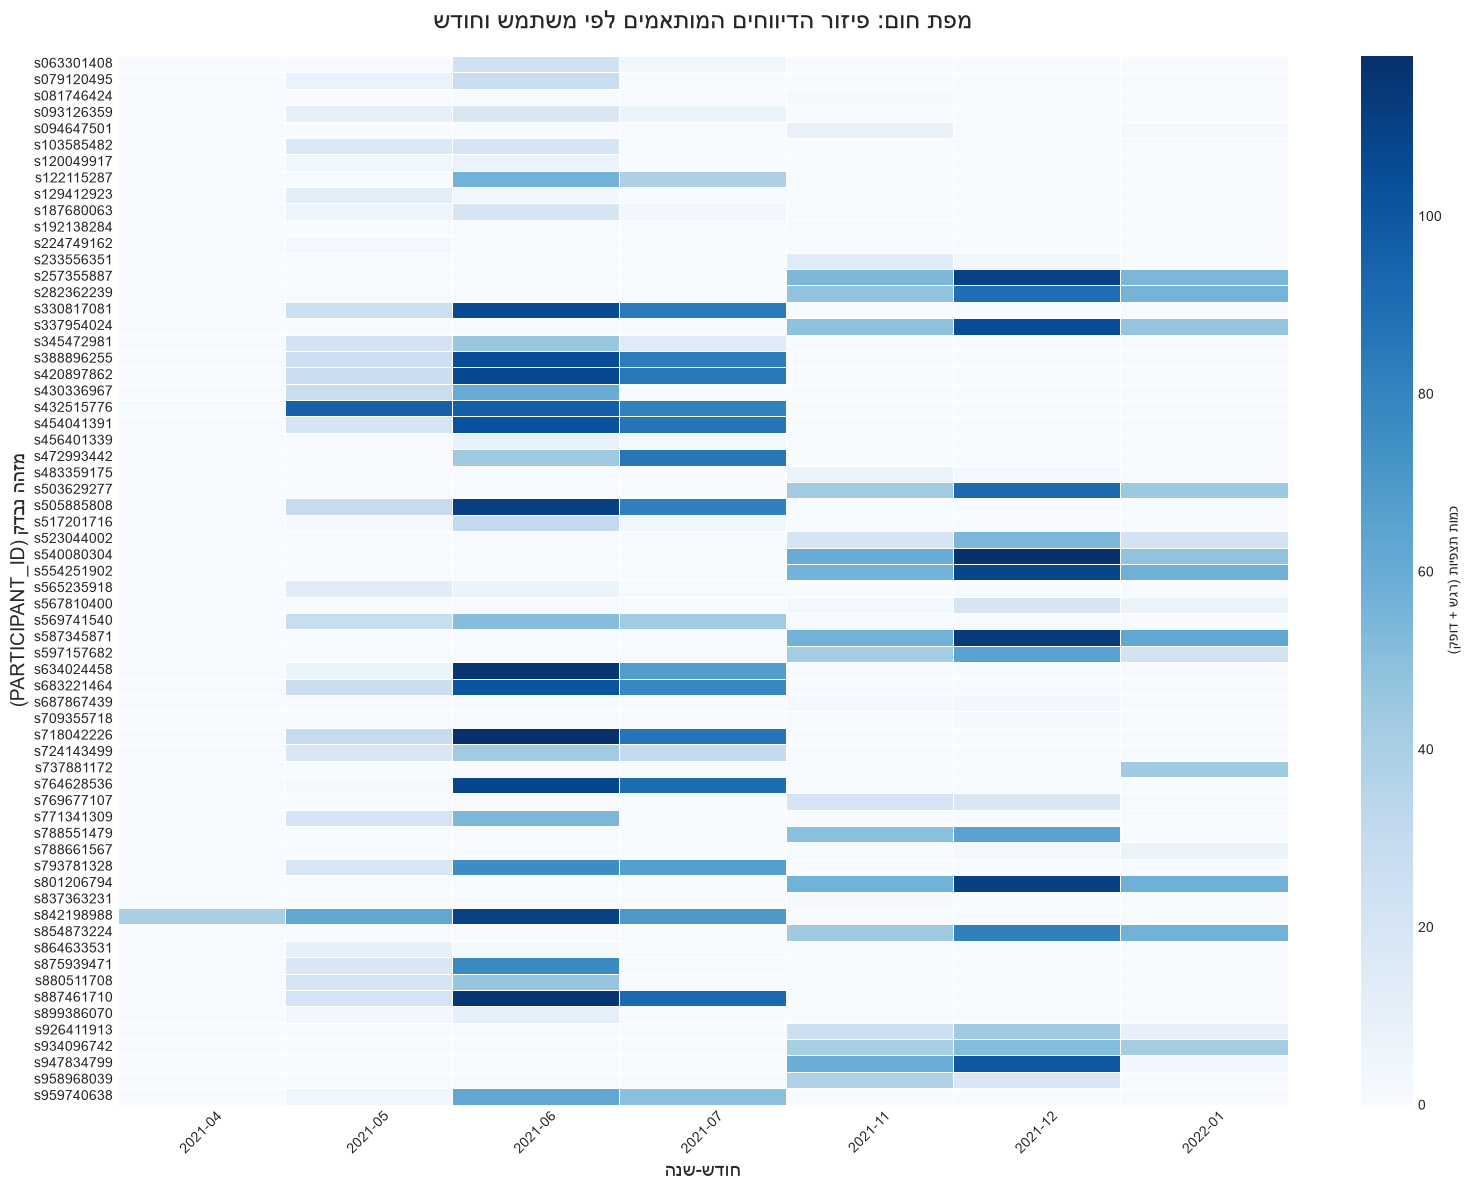

In [9]:
# יצירת עמודת חודש-שנה לקיבוץ הנתונים
df_matched['year_month'] = df_matched['timestamp'].dt.to_period('M').astype(str)

# יצירת טבלת ציר (Pivot) שסופרת כמה תצפיות יש לכל משתמש בכל חודש
pivot_data = df_matched.groupby([user_col, 'year_month']).size().unstack(fill_value=0)

plt.figure(figsize=(16, 12))
# ציור מפת החום
sns.heatmap(pivot_data, cmap="Blues", linewidths=.5, cbar_kws={'label': 'כמות תצפיות (רגש + דופק)'})
plt.title("מפת חום: פיזור הדיווחים המותאמים לפי משתמש וחודש", fontsize=18, pad=20)
plt.xlabel("חודש-שנה", fontsize=14)
plt.ylabel("מזהה נבדק (PARTICIPANT_ID)", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**תובנות ממפת החום:**
מפת החום ממחישה לנו אילו משתמשים היו הפעילים והעקביים ביותר ומתי. ריבועים כהים מייצגים חודשים עמוסים בדיווחים עבור משתמש מסוים. מידע זה קריטי עבורנו – אם נרצה בהמשך לבנות מודלים המבוססים על סדרות זמן (Time-Series Analysis) או לבחון מגמות של התדרדרות אישית, נדע בדיוק באילו משתמשים כדאי להתמקד (אלו שיש להם רצף דיווחים ללא "חורים" גדולים).

## 3. קשר בין פיזיולוגיה לרגש (נתונים גולמיים)
כדי להתחיל לענות על שאלת המחקר שלנו – האם יש קשר בין הפיזיולוגיה בחצי השעה שקדמה לדיווח לבין הרגש המדווח – נשרטט גרף כינור (Violin Plot). הגרף מציג את התפלגות קצב הלב (BPM גולמי) עבור כל אחד מסוגי הרגשות. בשלב זה, נסנן החוצה את השורות שבהן לא ניתן מענה לשאלת הרגש.

**תובנות (ואתגרים) מהנתונים הגולמיים:**
הגרף מראה לנו את הפיזור, אך קשה להסיק ממנו מסקנות חותכות. הסיבה המרכזית לכך היא **הבדלי בייסליין (Baseline) בין המשתמשים**: קצב לב של 85 פעימות בדקה יכול להיות מצב של מנוחה אצל משתמש אחד, ומצב של סטרס או פחד אצל משתמש אחר. הכנסת נתונים גולמיים כאלה למודל עלולה להוביל למסקנות שגויות, ולכן אנו חייבים לנרמל את הנתונים ברמה האישית.

## 4. נירמול הדופק (Z-Score אישי) וזיהוי מגמות
כדי לנטרל את ההבדלים הפיזיולוגיים הבסיסיים בין האנשים, ננרמל את נתוני הדופק. עבור כל משתמש נחשב את ממוצע הדופק שלו ואת סטיית התקן שלו, ונהפוך כל מדידה לציון תקן (Z-score). 
בגרף הבא, קו האפס (האדום) ייצג את מצב "הבייסליין הרגיל" של המשתמש. כל ערך חיובי יעיד על דופק שגבוה מהרגיל עבור אותו אדם, וערך שלילי יעיד על דופק נמוך מהרגיל. כך נוכל לבודד את התגובה הפיזיולוגית האמיתית.

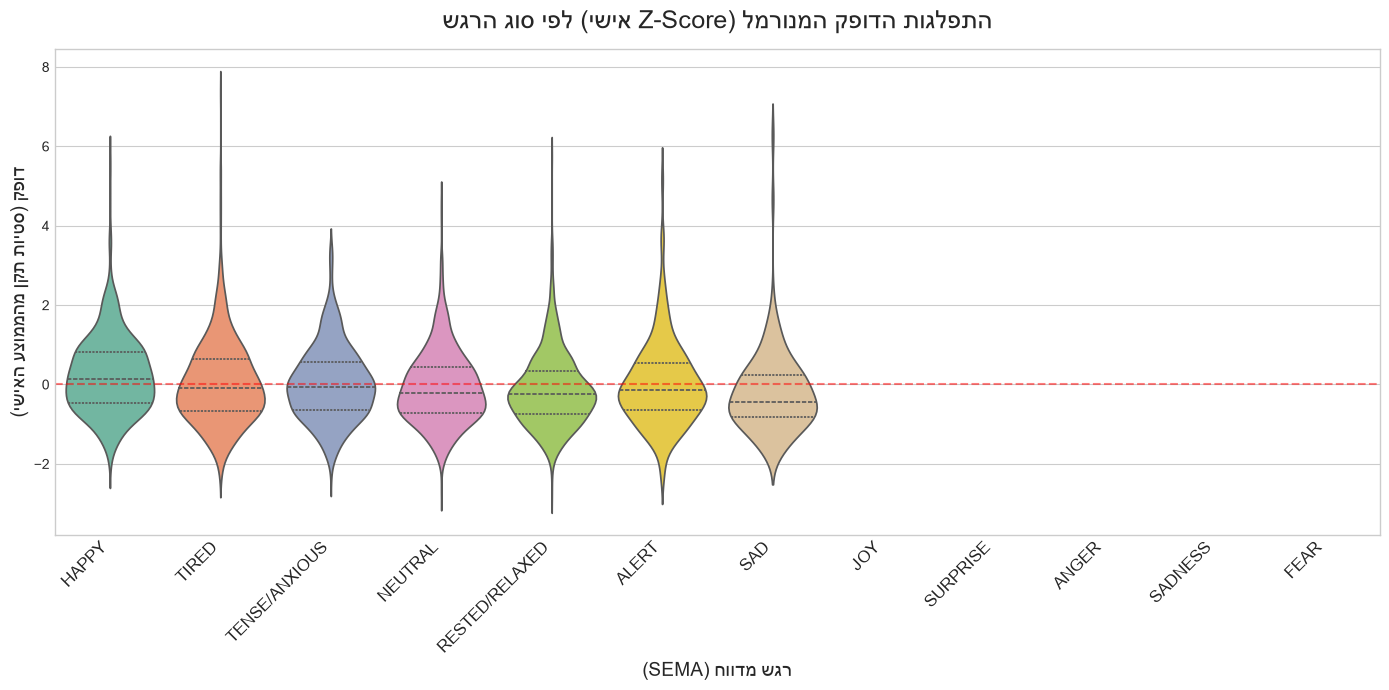

In [ ]:
# העתקת הנתונים כדי לא לפגוע בטבלה המקורית
df_normalized = df_plot.copy()

# 1. חישוב הממוצע וסטיית התקן של הדופק *לכל משתמש בנפרד*
user_stats = df_normalized.groupby(user_col)['value_numeric'].agg(['mean', 'std']).reset_index()
user_stats.columns = [user_col, 'user_mean_hr', 'user_std_hr']

# 2. מיזוג הנתונים חזרה לטבלה הראשית
df_normalized = df_normalized.merge(user_stats, on=user_col)

# 3. חישוב ציון התקן (Z-score): הדופק הנוכחי פחות הממוצע האישי, חלקי סטיית התקן האישית
# (אנו מחליפים סטיית תקן 0 ב-1 רק כדי למנוע שגיאת חלוקה באפס במקרים נדירים)
df_normalized['hr_zscore'] = (df_normalized['value_numeric'] - df_normalized['user_mean_hr']) / df_normalized['user_std_hr'].replace(0, 1)

# 4. ציור הגרף עם הנתונים המנורמלים
plt.figure(figsize=(14, 7))
sns.violinplot(data=df_normalized, x='data.MOOD', y='hr_zscore', palette="Set2", inner="quartile")

plt.title("התפלגות הדופק המנורמל (Z-Score אישי) לפי סוג הרגש", fontsize=18, pad=15)
plt.xlabel("רגש מדווח (SEMA)", fontsize=14)
plt.ylabel("דופק (סטיות תקן מהממוצע האישי)", fontsize=14)

# הוספת קו אדום על האפס - המייצג את קו הבייסליין (הממוצע) של המשתמש
plt.axhline(0, color='red', linestyle='--', alpha=0.5)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.tight_layout()
plt.show()

**תובנות מהנתונים המנורמלים:**
כעת התמונה נקייה יותר ומציגה שינויים יחסיים. ניתן לראות כיצד התפלגות הדופק ביחס לבייסליין משתנה בין רגשות שונים (לדוגמה: האם במצבי `TENSE/ANXIOUS` חציון ה-Z-score נוטה להיות מעל קו האפס ביחס למצבי `RESTED`?). 
פעולת הנירמול (Scaling) שעשינו כאן היא קריטית – היא מכניסה את כל המשתמשים לאותו קנה מידה, וזהו בדיוק סוג הנתונים שנרצה להזין למודל המכונה שלנו כדי לאפשר לו לבצע ניבוי אמין.